## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## Load Dataset

In [2]:
df=pd.read_csv("E-commerce_Customer_Segmentation_2026.csv")

## Basic Exploration

In [3]:
df.shape

(50000, 53)

In [4]:
df.head()

,customer_id,customer_segment,segment_category,age,age_group,gender,country,city,income_bracket,education_level,...,customer_value_category,activity_status,health_status,churn_risk_category,rfm_category,profitability_category,engagement_level,behavior_segment,device_preference,clv_category
0,CUST-000001,Consumer,High Value Inactive,70,65+,Male,Canada,Winnipeg,150K+,Professional,...,High,Dormant,Excellent,Low,Potential Loyalists,High Profit,Low,Regular Buyer,Multi-Device,High CLV
1,CUST-000002,Premium,High Value Inactive,53,45-54,Female,Germany,Essen,25K-50K,High School,...,Medium,Inactive,Excellent,Medium,At Risk,High Profit,Low,Occasional Buyer,Desktop-First,High CLV
2,CUST-000003,Consumer,High Value Inactive,82,65+,Male,Mexico,Puebla,75K-100K,Bachelors,...,Very High,Dormant,Excellent,Very Low,Champions,High Profit,Low,Regular Buyer,Multi-Device,High CLV
3,CUST-000004,Enterprise,High Value Active,18,18-24,Male,Singapore,Singapore,150K+,Masters,...,Very High,Active,Excellent,Very Low,Champions,High Profit,High,Frequent Buyer,Mobile-First,High CLV
4,CUST-000005,Premium,High Value Active,64,55-64,Male,United Arab Emirates,Fujairah,150K+,PhD,...,Medium,Active,Fair,Medium,Loyal,High Profit,Medium,Occasional Buyer,Desktop-First,High CLV


In [5]:
df.tail()

,customer_id,customer_segment,segment_category,age,age_group,gender,country,city,income_bracket,education_level,...,customer_value_category,activity_status,health_status,churn_risk_category,rfm_category,profitability_category,engagement_level,behavior_segment,device_preference,clv_category
49995,CUST-049996,Small Business,Low Value,22,18-24,Female,United States,San Antonio,50K-75K,PhD,...,Very Low,Inactive,Fair,High,Need Attention,High Profit,Low,Occasional Buyer,Multi-Device,Low CLV
49996,CUST-049997,Small Business,High Value Inactive,24,18-24,Male,Brazil,Rio de Janeiro,25K-50K,PhD,...,Very High,Dormant,Excellent,Low,Champions,High Profit,Medium,Regular Buyer,Multi-Device,High CLV
49997,CUST-049998,Consumer,High Value Inactive,29,25-34,Female,France,Strasbourg,100K-150K,Bachelors,...,Very High,Dormant,Excellent,Very Low,Champions,High Profit,Low,Regular Buyer,Multi-Device,High CLV
49998,CUST-049999,Consumer,High Value Active,74,65+,Male,Italy,Catania,100K-150K,Bachelors,...,High,Active,Good,Low,Champions,High Profit,Low,Frequent Buyer,Multi-Device,High CLV
49999,CUST-050000,Consumer,High Value Inactive,77,65+,Female,United Arab Emirates,Sharjah,75K-100K,Masters,...,Very High,Inactive,Excellent,Low,Loyal,High Profit,Low,Occasional Buyer,Desktop-First,High CLV


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   customer_id                    50000 non-null  object 
 1   customer_segment               50000 non-null  object 
 2   segment_category               50000 non-null  object 
 3   age                            50000 non-null  int64  
 4   age_group                      50000 non-null  object 
 5   gender                         50000 non-null  object 
 6   country                        50000 non-null  object 
 7   city                           50000 non-null  object 
 8   income_bracket                 50000 non-null  object 
 9   education_level                50000 non-null  object 
 10  employment_type                50000 non-null  object 
 11  marital_status                 50000 non-null  object 
 12  tenure_months                  50000 non-null 

In [7]:
df.columns

Index(['customer_id', 'customer_segment', 'segment_category', 'age',
       'age_group', 'gender', 'country', 'city', 'income_bracket',
       'education_level', 'employment_type', 'marital_status', 'tenure_months',
       'total_purchases', 'avg_order_value_usd', 'total_spent_usd',
       'purchase_frequency', 'days_since_last_purchase',
       'preferred_category_1', 'preferred_category_2', 'preferred_category_3',
       'shopping_channel', 'device_used', 'payment_method', 'return_count',
       'complaint_count', 'satisfaction_score', 'satisfaction_level',
       'loyalty_tier', 'email_open_rate', 'click_through_rate',
       'conversion_rate', 'social_media_presence',
       'customer_lifetime_value_usd', 'customer_acquisition_cost_usd',
       'customer_profitability_usd', 'recency_score', 'frequency_score',
       'monetary_score', 'rfm_score', 'churn_risk_score',
       'customer_health_score', 'dataset_year', 'customer_value_category',
       'activity_status', 'health_status',

In [8]:
df.dtypes

customer_id                       object
customer_segment                  object
segment_category                  object
age                                int64
age_group                         object
gender                            object
country                           object
city                              object
income_bracket                    object
education_level                   object
employment_type                   object
marital_status                    object
tenure_months                      int64
total_purchases                    int64
avg_order_value_usd              float64
total_spent_usd                  float64
purchase_frequency                object
days_since_last_purchase           int64
preferred_category_1              object
preferred_category_2              object
preferred_category_3              object
shopping_channel                  object
device_used                       object
payment_method                    object
return_count    

In [9]:
df.describe()

,age,tenure_months,total_purchases,avg_order_value_usd,total_spent_usd,days_since_last_purchase,return_count,complaint_count,satisfaction_score,email_open_rate,...,customer_lifetime_value_usd,customer_acquisition_cost_usd,customer_profitability_usd,recency_score,frequency_score,monetary_score,rfm_score,churn_risk_score,customer_health_score,dataset_year
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.0
mean,45.64802,59.748240,99.418460,505.366911,50266.546156,62.971240,9.511740,6.99380,3.007960,0.500319,...,57722.068910,102.453505,57619.615405,3.954040,4.122720,3.717700,11.794460,26.84122,86.674100,2026.0
std,18.36795,34.310128,57.780178,285.604037,44071.209164,93.281404,5.782592,4.32425,1.417976,0.289515,...,52437.283546,56.373987,52437.172654,1.478949,1.077573,1.358633,2.680507,19.20729,16.107113,0.0
min,18.00000,1.000000,0.000000,10.050000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000,...,0.000000,5.010000,-199.870000,1.000000,1.000000,1.000000,3.000000,0.00000,30.000000,2026.0
25%,30.00000,30.000000,49.000000,259.067500,13893.577500,2.000000,4.000000,3.00000,2.000000,0.251000,...,15488.650000,53.820000,15372.800000,3.000000,3.000000,3.000000,10.000000,10.00000,75.000000,2026.0
50%,45.00000,60.000000,99.000000,504.790000,37541.625000,19.000000,10.000000,7.00000,3.000000,0.500000,...,42236.310000,102.320000,42129.690000,5.000000,4.000000,4.000000,12.000000,25.00000,95.000000,2026.0
75%,60.00000,90.000000,150.000000,752.702500,76811.242500,77.000000,15.000000,11.00000,4.000000,0.752000,...,86714.875000,151.260000,86608.330000,5.000000,5.000000,5.000000,14.000000,40.00000,100.000000,2026.0
max,84.00000,119.000000,199.000000,999.990000,198574.140000,365.000000,19.000000,14.00000,5.000000,1.000000,...,294634.150000,200.000000,294479.720000,5.000000,5.000000,5.000000,15.000000,100.00000,100.000000,2026.0


## Data Cleaning

In [10]:
df.isnull().sum()

customer_id                          0
customer_segment                     0
segment_category                     0
age                                  0
age_group                            0
gender                               0
country                              0
city                                 0
income_bracket                       0
education_level                      0
employment_type                      0
marital_status                       0
tenure_months                        0
total_purchases                      0
avg_order_value_usd                  0
total_spent_usd                      0
purchase_frequency                   0
days_since_last_purchase             0
preferred_category_1                 0
preferred_category_2             16743
preferred_category_3             33257
shopping_channel                     0
device_used                          0
payment_method                       0
return_count                         0
complaint_count          

In [11]:
rmf_features=[
    'days_since_last_purchase',
    'total_purchases',
    'total_spent_usd'
]
df[rmf_features].isna().sum()

days_since_last_purchase    0
total_purchases             0
total_spent_usd             0
dtype: int64

In [12]:
df['preferred_category_2'] = df['preferred_category_2'].fillna('No Preference')
df['preferred_category_3'] = df['preferred_category_3'].fillna('No Preference')

In [13]:
df['loyalty_tier'] = df['loyalty_tier'].fillna('Unknown')

In [14]:
df['social_media_presence'] = df['social_media_presence'].fillna('None/Unknown')

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
rfm_features = [
    'days_since_last_purchase',
    'total_purchases',
    'total_spent_usd'
]

rfm = df[rfm_features].copy()

rfm.head()

,days_since_last_purchase,total_purchases,total_spent_usd
0,63,28,25552.80
1,342,75,22564.50
2,64,163,108217.33
3,2,192,117811.20
4,4,31,20201.15


Observation: RMF is a customer segmentation technique used to understand customer purchasing behavior.

## Descriptive Statistics

In [17]:
df[['avg_order_value_usd',
   'total_purchases',
   'customer_lifetime_value_usd']].describe()

,avg_order_value_usd,total_purchases,customer_lifetime_value_usd
count,50000.000000,50000.000000,50000.000000
mean,505.366911,99.418460,57722.068910
std,285.604037,57.780178,52437.283546
min,10.050000,0.000000,0.000000
25%,259.067500,49.000000,15488.650000
50%,504.790000,99.000000,42236.310000
75%,752.702500,150.000000,86714.875000
max,999.990000,199.000000,294634.150000


In [18]:
print("Average Order Value:",
      df['avg_order_value_usd'].mean())

print("Average Purchase Frequency:",
      df['total_purchases'].mean())

print("Average Customer Lifetime Value:",
      df['customer_lifetime_value_usd'].mean())

Average Order Value: 505.36691060000004
Average Purchase Frequency: 99.41846
Average Customer Lifetime Value: 57722.0689104


## Plotting

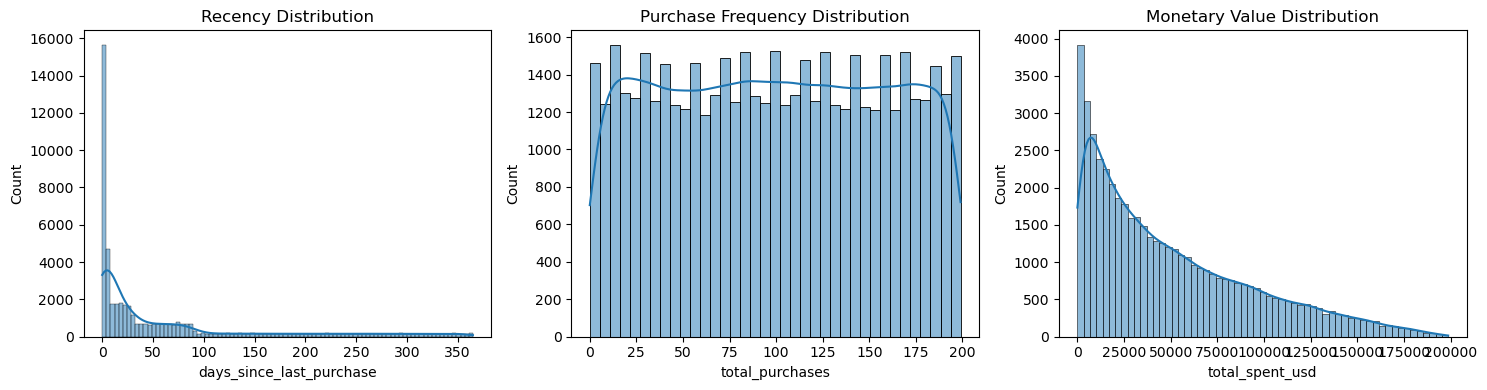

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['days_since_last_purchase'], kde=True, ax=axes[0])
axes[0].set_title('Recency Distribution')

sns.histplot(df['total_purchases'], kde=True, ax=axes[1])
axes[1].set_title('Purchase Frequency Distribution')

sns.histplot(df['total_spent_usd'], kde=True, ax=axes[2])
axes[2].set_title('Monetary Value Distribution')

plt.tight_layout()
plt.show()

## Standardize Data

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(rfm)

## Elbow Method

In [21]:
from sklearn.cluster import KMeans

In [22]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

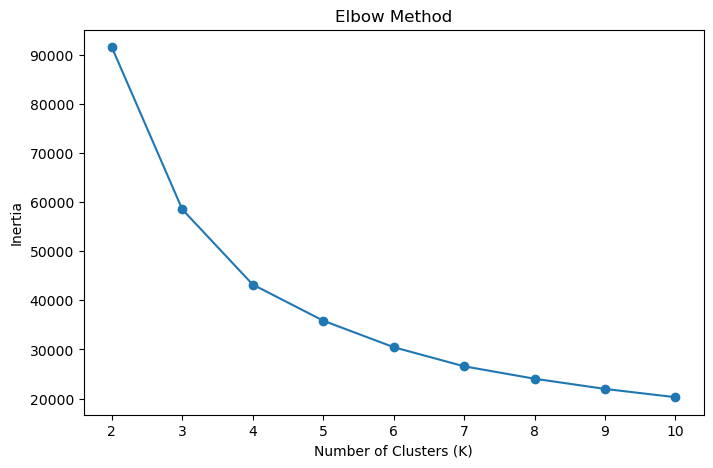

In [23]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), inertia, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()

## Apply K-means

In [24]:
optimal_k=4

In [25]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

## Profile the cluster

In [26]:
cluster_profile = df.groupby('Cluster')[[
    'days_since_last_purchase',
    'total_purchases',
    'total_spent_usd'
]].mean()

cluster_profile

,days_since_last_purchase,total_purchases,total_spent_usd
Cluster,,,
0,26.331733,127.564297,46280.097621
1,28.358826,40.133805,17302.745790
2,39.618684,162.350769,121409.385374
3,266.209710,94.091353,43487.401063


## Customer Count per Cluster

In [27]:
cluster_counts = df['Cluster'].value_counts().sort_index()

cluster_counts

Cluster
0    16245
1    17234
2     9559
3     6962
Name: count, dtype: int64

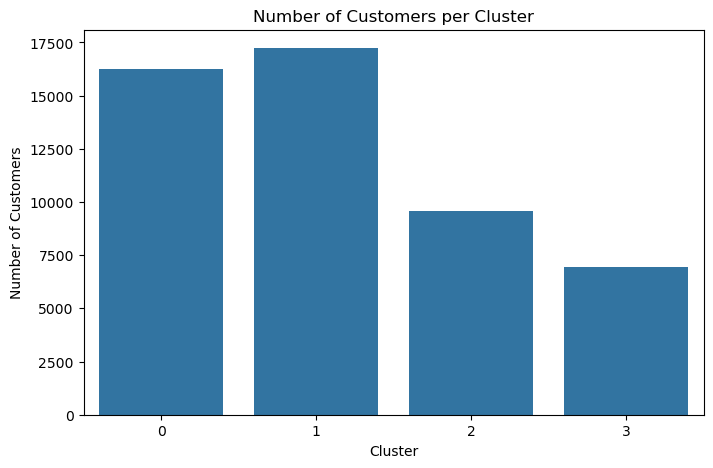

In [28]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Number of Customers per Cluster')

plt.show()

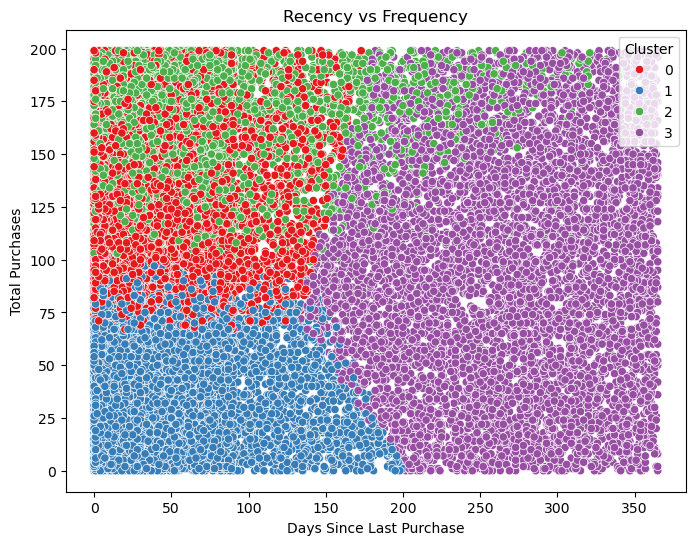

In [30]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='days_since_last_purchase',
    y='total_purchases',
    hue='Cluster',
    palette='Set1'
)

plt.title('Recency vs Frequency')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Total Purchases')

plt.show()

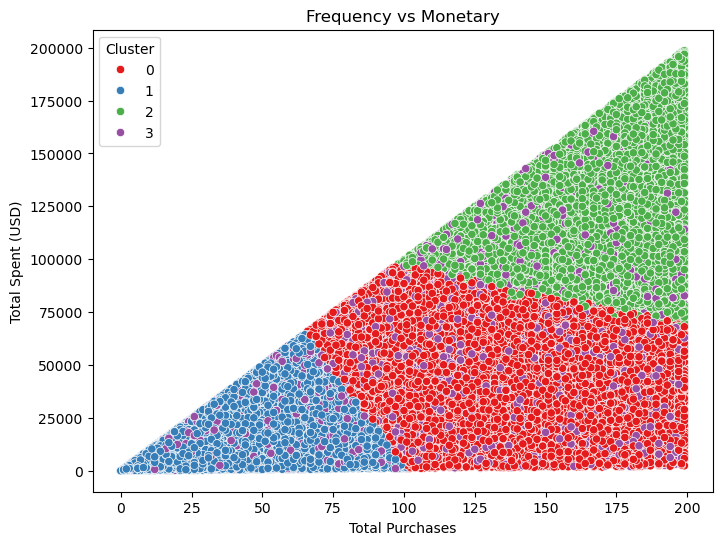

In [31]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='total_purchases',
    y='total_spent_usd',
    hue='Cluster',
    palette='Set1'
)

plt.title('Frequency vs Monetary')
plt.xlabel('Total Purchases')
plt.ylabel('Total Spent (USD)')

plt.show()

## Proper Cluster Summary

In [32]:
cluster_summary = df.groupby('Cluster').agg(
    Customers=('customer_id', 'count'),
    Avg_Recency=('days_since_last_purchase', 'mean'),
    Avg_Frequency=('total_purchases', 'mean'),
    Avg_Monetary=('total_spent_usd', 'mean'),
    Avg_AOV=('avg_order_value_usd', 'mean'),
    Avg_CLV=('customer_lifetime_value_usd', 'mean')
).round(2)

cluster_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_AOV,Avg_CLV
Cluster,,,,,,
0,16245,26.33,127.56,46280.10,404.79,53059.68
1,17234,28.36,40.13,17302.75,469.91,19893.77
2,9559,39.62,162.35,121409.39,757.75,139505.78
3,6962,266.21,94.09,43487.40,481.30,49951.74


In [33]:
df.duplicated().sum()

np.int64(0)

In [34]:
df.isna().sum()

customer_id                      0
customer_segment                 0
segment_category                 0
age                              0
age_group                        0
gender                           0
country                          0
city                             0
income_bracket                   0
education_level                  0
employment_type                  0
marital_status                   0
tenure_months                    0
total_purchases                  0
avg_order_value_usd              0
total_spent_usd                  0
purchase_frequency               0
days_since_last_purchase         0
preferred_category_1             0
preferred_category_2             0
preferred_category_3             0
shopping_channel                 0
device_used                      0
payment_method                   0
return_count                     0
complaint_count                  0
satisfaction_score               0
satisfaction_level               0
loyalty_tier        